In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convolution

In [ ]:
lena = cv2.imread('../test_assets/Lena.jpg', 0)
box=cv2.imread('../test_assets/box.jpg', 0)

In [55]:
kernel1 = np.array([
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]
], dtype=np.float32)

kernel3=np.array([
    [-2, 0, -1, 0, 0],
    [0, -2, -1, 0, 0],
    [-1,-1,1,1,1,],
    [0,0,1,2,0],
    [0,0,1,0,2]
], dtype=np.float32)


kernel2 = np.array([[-1, 0, 1],
                    [-1, 0, 1],
                    [-1, 0, 1]], dtype=np.float32)

In [56]:
def gaussFn(x,y,sigma):
    return (1/2*np.pi*sigma**2)*(np.exp(-(x**2+y**2)/(2*sigma**2)))

In [57]:
def gaussKernel(size,sigma):
    k=size//2
    coords=np.arange(-k,k+1)
    x,y=np.meshgrid(coords,coords)
    k=gaussFn(x,y,sigma)
    k/=np.sum(k)
    return k

In [58]:
def gaussXkernel(size,sigma):
    k=size//2
    coords=np.arange(-k,k+1)
    x,y=np.meshgrid(coords,coords)
    gv=gaussFn(x,y,sigma)
    gx=-(x/sigma**2)*gv
    gx/=np.sum(gx)
    return gx

In [59]:
def gaussYkernel(size,sigma):
    k=size//2
    coords=np.arange(-k,k+1)
    x,y=np.meshgrid(coords,coords)
    gv=gaussFn(x,y,sigma)
    gy=-(y/sigma**2)*gv
    gy/=np.sum(gy)
    return gy

In [60]:
def logFunction(x,y,sigma):
    x2y2 = x**2 + y**2
    return -(1 / (np.pi * sigma**4)) * (1 - x2y2 / (2 * sigma**2)) * np.exp(-x2y2 / (2 * sigma**2))

In [61]:
def log_kernel(size, sigma):

    k=size//2
    coords=np.arange(-k, k + 1)
    x,y=np.meshgrid(coords, coords)
    kernel = logFunction(x, y, sigma)

    return kernel

In [ ]:
def int_kernel(kernel, min_val, max_val):

    k_min = np.min(kernel)
    k_max = np.max(kernel)
    norm_kernel = (kernel - k_min) / (k_max - k_min) 
    int_kernel = norm_kernel * (max_val - min_val) + min_val
    int_kernel = np.round(int_kernel).astype(int)
    return int_kernel

In [62]:
# img_conv = cv2.filter2D(image, ddepth=cv2.CV_32F, kernel= kernel1)

def convolution2D(image, kernel):
    kernel=np.flip(kernel)
    ih,iw=image.shape
    kh,kw=kernel.shape
    border=kh//2
    bordered_image=cv2.copyMakeBorder(image,border,border,border,border,cv2.BORDER_CONSTANT,value=0)
    result = np.zeros((ih, iw), dtype=np.float32)
    for j in range(ih):
        for i in range(iw):
            region=bordered_image[j:j+kh,i:i+kw]
            mul=np.multiply(region,kernel)
            result[j,i]=np.sum(mul)
    return result

In [63]:
# img_conv = cv2.filter2D(src=image, ddepth=cv2.CV_32F, kernel= kernel1)

def convolution2D2(image, kernel):
    kernel=np.flip(kernel)
    ih,iw=image.shape
    kh,kw=kernel.shape
    # border=kh//2
    bordered_image=cv2.copyMakeBorder(image,3,1,3,1,cv2.BORDER_CONSTANT,value=0)
    result = np.zeros((ih, iw), dtype=np.float32)
    for j in range(ih):
        for i in range(iw):
            region=bordered_image[j:j+kh,i:i+kw]
            mul=np.multiply(region,kernel)
            result[j,i]=np.sum(mul)
    return result

In [64]:
lena_conv1 = convolution2D2(lena, kernel3)
lena_normalized1 = np.round(
    cv2.normalize(
        src=lena_conv1,         # input array to normalize
        dst=None,               # output array (None means create new)
        alpha=0,                # lower range value after normalization
        beta=255,               # upper range value after normalization
        norm_type=cv2.NORM_MINMAX, # normalization type (min-max scaling)
        dtype=cv2.CV_32F        # output data type (optional, here not used)
    )
).astype(np.uint8)              # convert to 8-bit unsigned integer

Text(0.5, 1.0, 'Convolution')

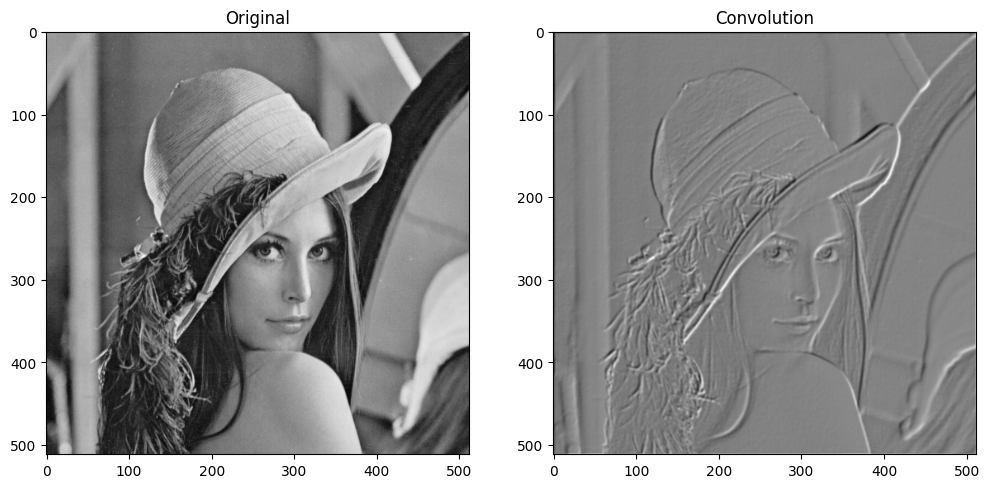

In [65]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(lena, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(lena_normalized1, cmap="gray")
plt.title("Convolution")

In [122]:
logK=log_kernel(9,1)

Text(0.5, 1.0, 'Log Convolution')

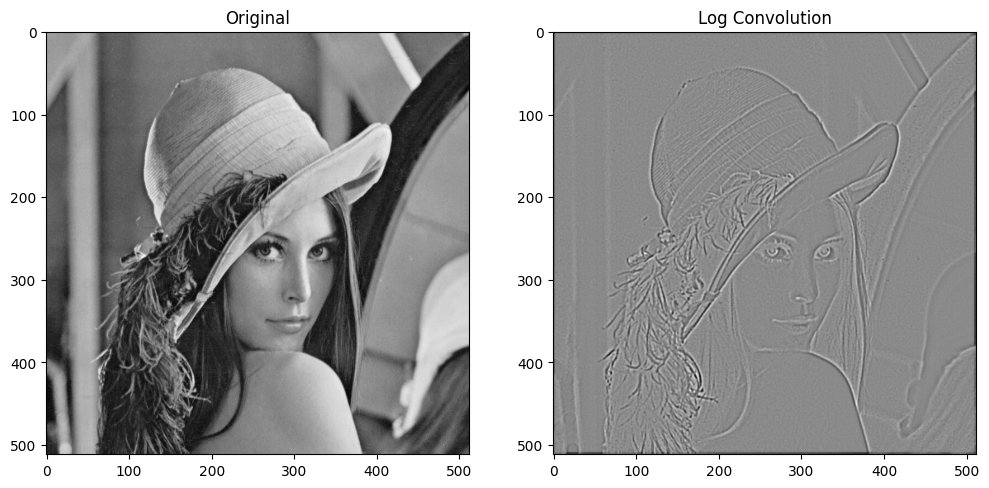

In [123]:
log_lena= convolution2D(lena, logK)
log_lena_normalized = np.round(cv2.normalize(log_lena, None, 0, 255, cv2.NORM_MINMAX)).astype(np.uint8)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(lena, cmap="gray")
plt.title("Original")
plt.subplot(1,2,2)
plt.imshow(log_lena_normalized, cmap="gray")
plt.title("Log Convolution")


# Edge Detection

In [125]:
gx=gaussXkernel(7,1.0)
gy=gaussYkernel(7,1.0)

Text(0.5, 1.0, 'Gaussian Derivative Kernel in Y Direction')

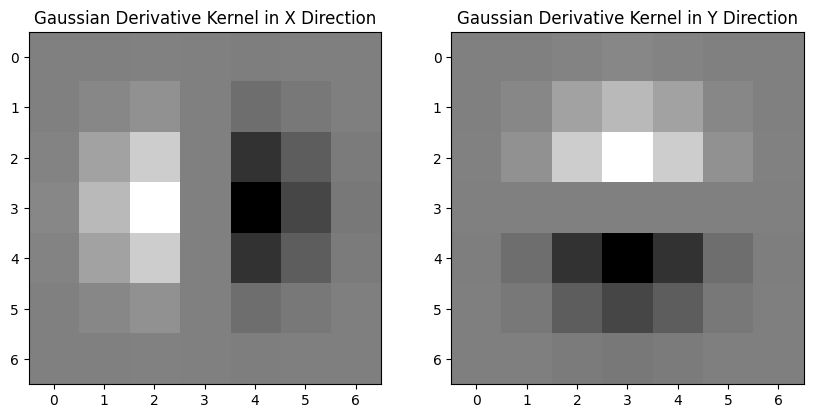

In [167]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(gx, cmap="gray")
plt.title("Gaussian Derivative Kernel in X Direction")

plt.subplot(1, 2, 2)
plt.imshow(gy, cmap="gray")
plt.title("Gaussian Derivative Kernel in Y Direction")

In [126]:
Gx=cv2.filter2D(src=lena, ddepth=cv2.CV_32F, kernel=gx).astype(np.float32)
Gx_n=np.round(cv2.normalize(src=Gx,dst=None,alpha=0,beta=255,norm_type=cv2.NORM_MINMAX)).astype(np.uint8)


In [127]:
Gy=cv2.filter2D(src=lena, ddepth=cv2.CV_32F, kernel=gy).astype(np.float32)
Gy_n=np.round(cv2.normalize(src=Gy,dst=None,alpha=0,beta=255,norm_type=cv2.NORM_MINMAX)).astype(np.uint8)


In [128]:
G_mag=cv2.magnitude(Gx.astype(np.float32), Gy.astype(np.float32))
G_mag_norm=np.round(cv2.normalize(src=G_mag,dst=None,alpha=0,beta=255,norm_type=cv2.NORM_MINMAX)).astype(np.uint8)

In [129]:
def double_th(img, ht, lt, v):
    h, w = img.shape
    op = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if img[i, j] >= ht:
                op[i, j] = 255
            elif img[i, j] >= lt:
                op[i, j] = v
            else:
                op[i, j] = 0
    return op

double_t = double_th(G_mag_norm, 150, 50, 128)

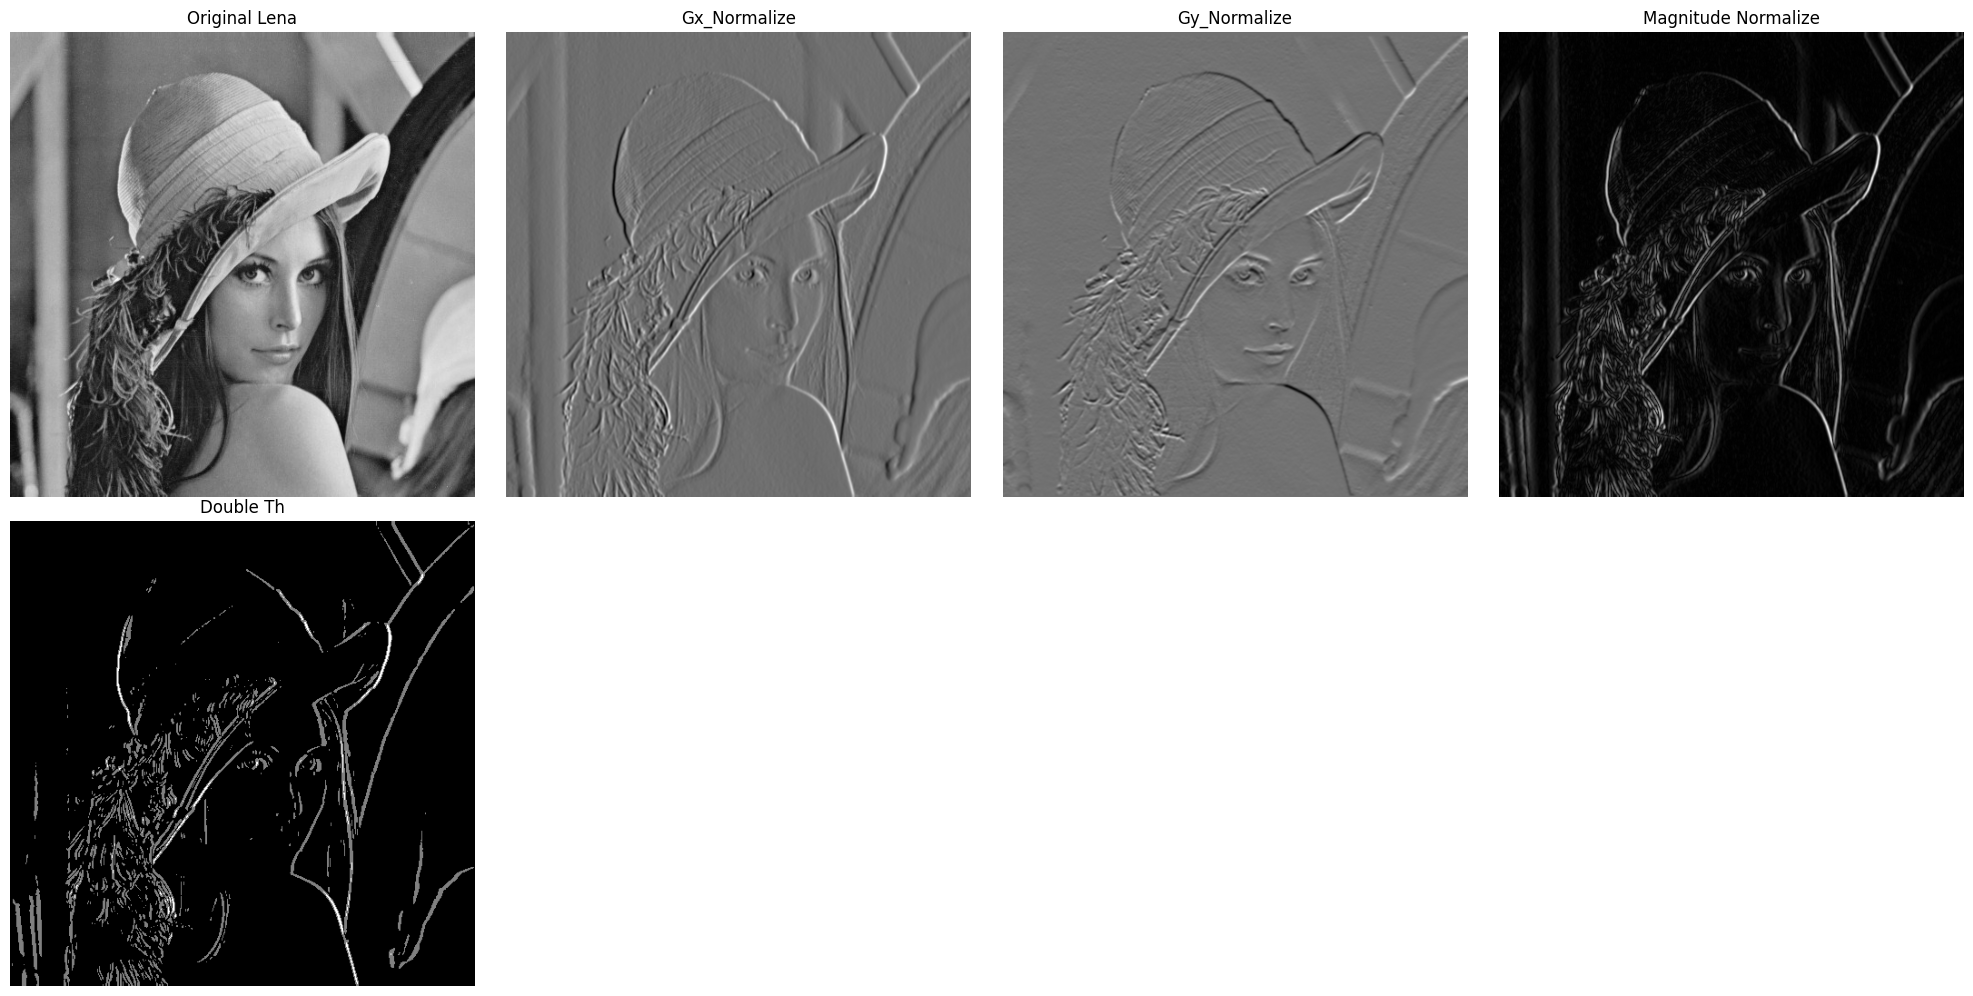

In [130]:
plt.figure(figsize=(20,10))

plt.subplot(2,4,1)
plt.title("Original Lena")
plt.imshow(lena, cmap="gray")
plt.axis("off")

plt.subplot(2,4,2)
plt.title("Gx_Normalize")
plt.imshow(Gx_n, cmap="gray")
plt.axis("off")

plt.subplot(2,4,3)
plt.title("Gy_Normalize")
plt.imshow(Gy_n, cmap="gray")
plt.axis("off")

plt.subplot(2,4,4)
plt.title("Magnitude Normalize")
plt.imshow(G_mag_norm, cmap="gray")
plt.axis("off")

plt.subplot(2,4,5)
plt.title("Double Th")
plt.imshow(double_t, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [158]:
logKEdge=log_kernel(9,1)

logC=cv2.filter2D(src=lena, ddepth=cv2.CV_32F, kernel=logKEdge).astype(np.float32)

In [159]:
def zero_crossing(img,th):
    h,w=img.shape
    st_map=np.zeros((h,w), dtype=np.float32)
    ed_map=np.zeros((h,w), dtype=np.uint8)

    for i in range(1,h-1):
        for j in range(1,w-1):
            root=img[i,j]
            n1=img[i-1,j]
            n2=img[i+1,j]
            n3=img[i,j-1]
            n4=img[i,j+1]

            if (n1*n2<0) or (n3*n4<0):
                s=(np.abs(root-n1)+np.abs(root-n2)+np.abs(root-n3)+np.abs(root-n4))
                st_map[i,j]=s

                if st_map[i,j]>th:
                    ed_map[i,j]=255
    return st_map,ed_map

In [160]:
st_map,ed_map=zero_crossing(logC, 10)

st_n=np.round(cv2.normalize(src=st_map, dst=None, alpha=0, beta=255,norm_type=cv2.NORM_MINMAX)).astype(np.uint8)

ed_n=np.round(cv2.normalize(src=ed_map, dst=None, alpha=0, beta=255,norm_type=cv2.NORM_MINMAX)).astype(np.uint8)

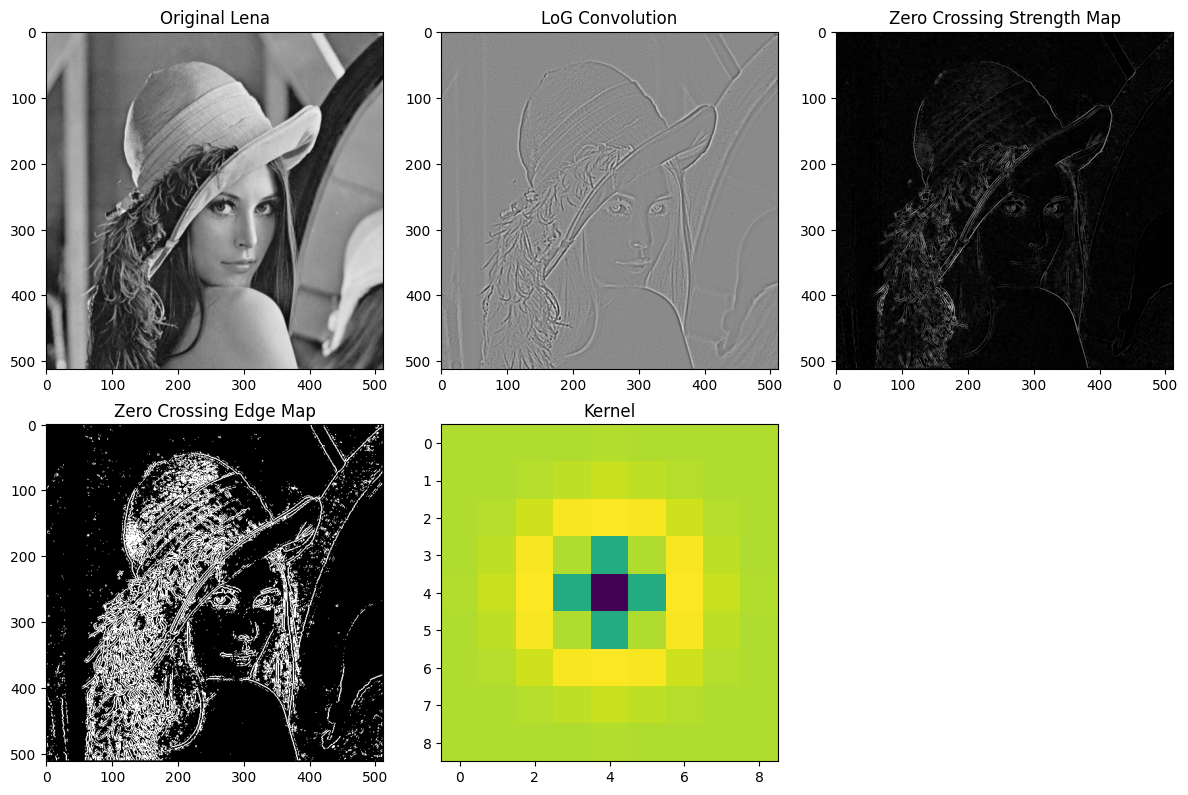

In [161]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Original Lena")
plt.imshow(lena, cmap="gray")

plt.subplot(2,3,2)
plt.title("LoG Convolution")
plt.imshow(logC, cmap="gray")

plt.subplot(2,3,3)
plt.title("Zero Crossing Strength Map")
plt.imshow(st_map, cmap="gray")

plt.subplot(2,3,4)
plt.title("Zero Crossing Edge Map")
plt.imshow(ed_map, cmap="gray")

plt.subplot(2,3,5)
plt.title("Kernel")
plt.imshow(logKEdge)

plt.tight_layout()
plt.show()

In [162]:
def hysteresis_threshold(img, high_th, low_th):
    """
    Hysteresis thresholding for edge detection
    - Pixels >= high_th: Strong edges (255)
    - Pixels >= low_th and < high_th: Weak edges (128)
    - Pixels < low_th: Non-edges (0)
    """
    h, w = img.shape
    result = np.zeros((h, w), dtype=np.uint8)
    
    # Classify pixels
    strong_edges = (img >= high_th)
    weak_edges = (img >= low_th) & (img < high_th)
    
    result[strong_edges] = 255
    result[weak_edges] = 128
    
    return result

In [163]:
def edge_tracking(img, high_th, low_th):
    """
    Edge tracking by hysteresis - connect weak edges to strong edges
    """
    h, w = img.shape
    
    # Get initial strong and weak edges
    strong_mask = (img >= high_th)
    weak_mask = (img >= low_th) & (img < high_th)
    
    # Output edge map
    edges = np.zeros((h, w), dtype=np.uint8)
    edges[strong_mask] = 255
    
    # Track weak edges connected to strong edges
    changed = True
    while changed:
        changed = False
        for i in range(1, h-1):
            for j in range(1, w-1):
                if weak_mask[i, j] and edges[i, j] == 0:
                    # Check 8-connected neighbors
                    neighbors = edges[i-1:i+2, j-1:j+2]
                    if np.any(neighbors == 255):
                        edges[i, j] = 255
                        changed = True
    
    return edges

In [164]:
# Apply hysteresis thresholding on gradient magnitude
high_threshold = 150
low_threshold = 50

# Step 1: Initial thresholding (strong=255, weak=128, background=0)
hyst_result = hysteresis_threshold(G_mag_norm, high_threshold, low_threshold)

# Step 2: Edge tracking (connect weak edges to strong edges)
final_edges = edge_tracking(G_mag_norm, high_threshold, low_threshold)

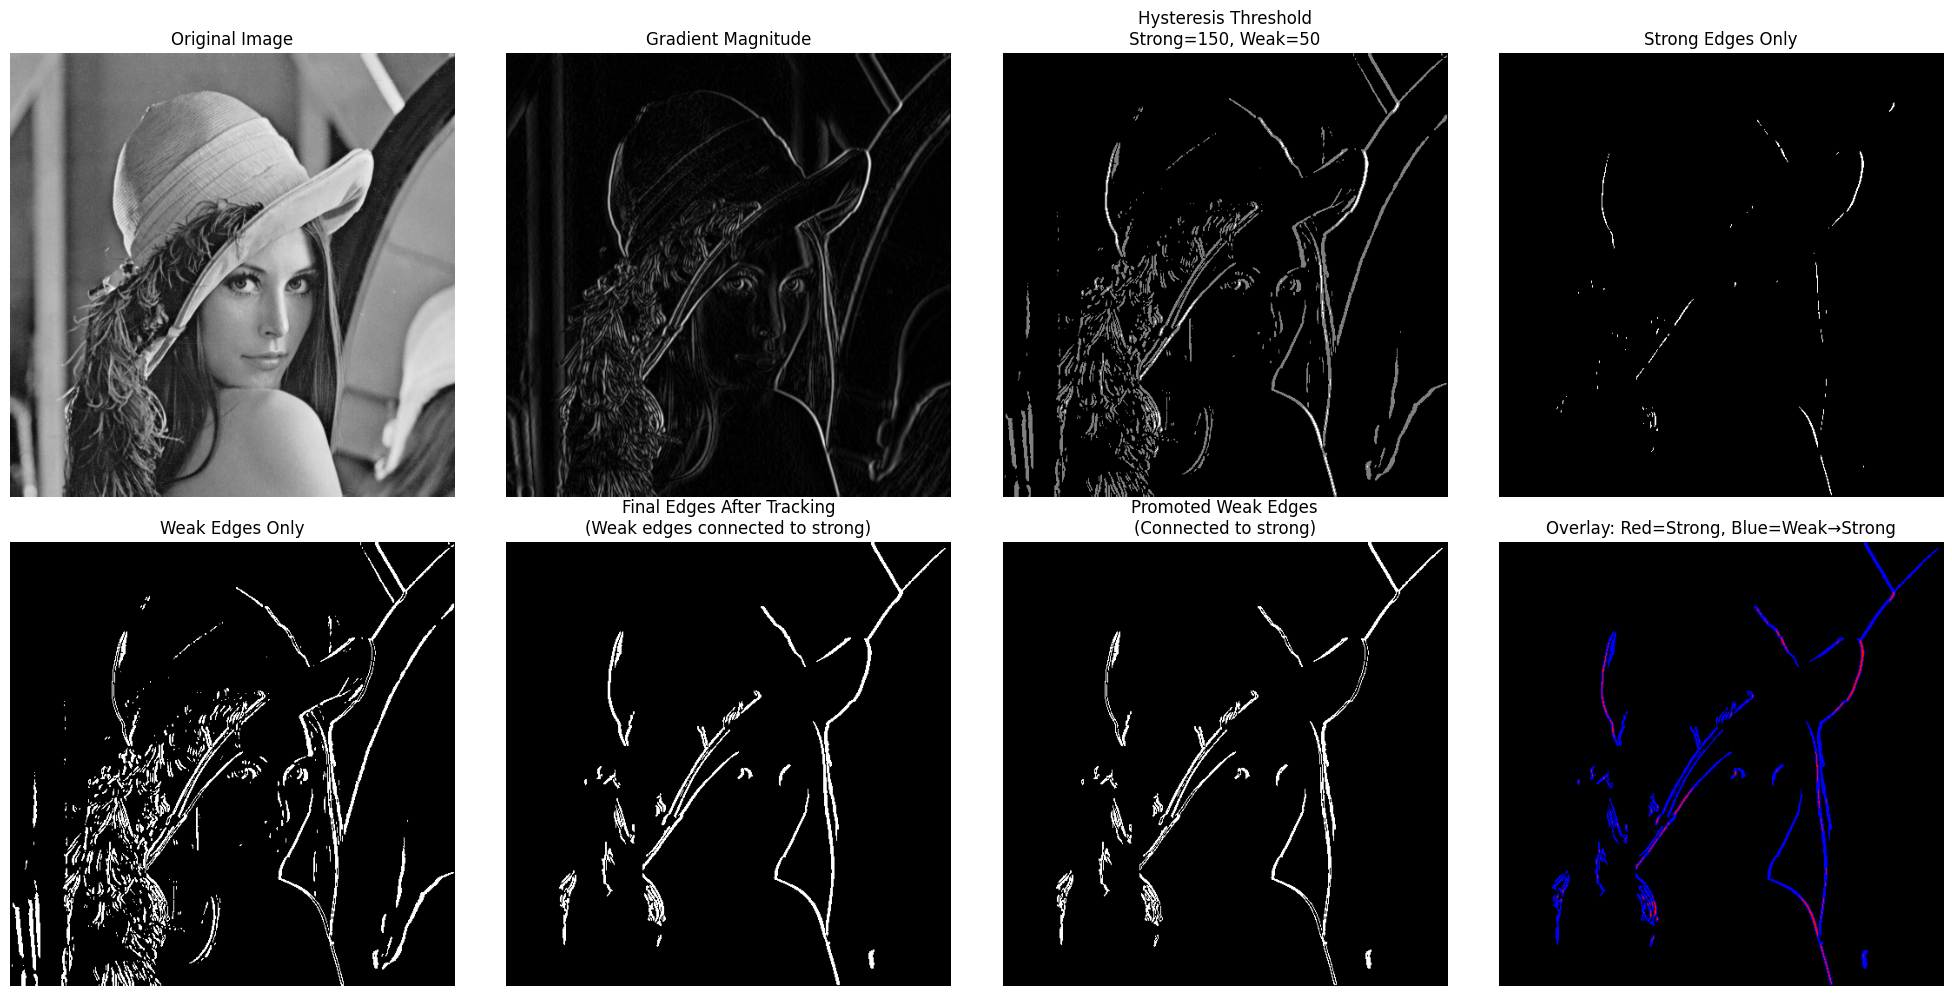

Strong edges: 919 pixels
Initial weak edges: 18402 pixels
Promoted weak edges: 7470 pixels
Total final edges: 8389 pixels


In [165]:
# Visualization
plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
plt.title("Original Image")
plt.imshow(lena, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.title("Gradient Magnitude")
plt.imshow(G_mag_norm, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.title(f"Hysteresis Threshold\nStrong={high_threshold}, Weak={low_threshold}")
plt.imshow(hyst_result, cmap="gray")
plt.axis("off")

# Show only strong edges
strong_only = np.zeros_like(hyst_result)
strong_only[hyst_result == 255] = 255
plt.subplot(2, 4, 4)
plt.title("Strong Edges Only")
plt.imshow(strong_only, cmap="gray")
plt.axis("off")

# Show only weak edges
weak_only = np.zeros_like(hyst_result)
weak_only[hyst_result == 128] = 255
plt.subplot(2, 4, 5)
plt.title("Weak Edges Only")
plt.imshow(weak_only, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.title("Final Edges After Tracking\n(Weak edges connected to strong)")
plt.imshow(final_edges, cmap="gray")
plt.axis("off")

# Show difference (weak edges that were promoted)
promoted_edges = np.zeros_like(final_edges)
promoted_edges[(hyst_result == 128) & (final_edges == 255)] = 255
plt.subplot(2, 4, 7)
plt.title("Promoted Weak Edges\n(Connected to strong)")
plt.imshow(promoted_edges, cmap="gray")
plt.axis("off")

# Overlay visualization
plt.subplot(2, 4, 8)
plt.title("Overlay: Red=Strong, Blue=Weak→Strong")
h, w = G_mag_norm.shape 
overlay = np.zeros((h, w, 3), dtype=np.uint8)
overlay[strong_only == 255] = [255, 0, 0]  # Red for original strong
overlay[promoted_edges == 255] = [0, 0, 255]  # Blue for promoted weak
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

# Print statistics
print(f"Strong edges: {np.sum(strong_only == 255)} pixels")
print(f"Initial weak edges: {np.sum(weak_only == 255)} pixels")
print(f"Promoted weak edges: {np.sum(promoted_edges == 255)} pixels")
print(f"Total final edges: {np.sum(final_edges == 255)} pixels")